# QoS–QoE Analysis using Spectral Clustering
This notebook performs the following pipeline:
1. Data Loading
2. Data Exploration
3. Preprocessing
4. Feature Scaling
5. PCA Visualization
6. Elbow Method (for reference)
7. Spectral Clustering
8. Cluster Visualization
9. MOS Analysis per Cluster
10. Attribute Relationships inside Clusters
11. QoE Anomaly Detection
12. Visualization of Anomalies


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, SpectralClustering

print('Libraries loaded successfully')

Libraries loaded successfully


## Load Dataset

In [2]:
df = pd.read_csv('../data/engineered_dataset.csv')
print('Dataset shape:', df.shape)
df.head()

Dataset shape: (300, 34)


,QoS_bandwidth,QoS_packet-loss,QoS_delay,QoS_jitter,V_id-video,V_norm-bitrate,V_complexity,V_complexity-class,QoA_resolution,QoA-bitrate,...,screen_width,screen_height,screen_pixels,screen_dim_w,screen_dim_h,screen_area,V_content_Movie,QoD_carte-class_Radeon HD 7610M,QoD_carte-class_VGA compatible controller,QoD-screen_blug-type_LVDS
0,1024,0.0,0.360,0.043,3,6.422284,5.874106,0,144,79.0,...,1366,768,1049088,361,203,73283,True,True,False,True
1,1024,0.0,0.435,0.071,3,6.422284,5.874106,0,144,79.0,...,1920,1200,2304000,508,317,161036,True,False,False,False
2,1024,0.0,0.403,0.033,3,6.422284,5.874106,0,144,79.0,...,1366,768,1049088,361,203,73283,True,True,False,True
3,1024,0.0,0.499,0.018,3,6.422284,5.874106,0,144,79.0,...,1366,768,1049088,361,203,73283,True,True,False,True
4,1024,0.0,0.472,0.034,3,6.422284,5.874106,0,144,79.0,...,1366,768,1049088,361,203,73283,True,True,False,True


## Dataset Information

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 34 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   QoS_bandwidth                              300 non-null    int64  
 1   QoS_packet-loss                            300 non-null    float64
 2   QoS_delay                                  300 non-null    float64
 3   QoS_jitter                                 300 non-null    float64
 4   V_id-video                                 300 non-null    int64  
 5   V_norm-bitrate                             300 non-null    float64
 6   V_complexity                               300 non-null    float64
 7   V_complexity-class                         300 non-null    int64  
 8   QoA_resolution                             300 non-null    int64  
 9   QoA-bitrate                                300 non-null    float64
 10  QoA-frame_rate            

In [4]:
df.describe()

,QoS_bandwidth,QoS_packet-loss,QoS_delay,QoS_jitter,V_id-video,V_norm-bitrate,V_complexity,V_complexity-class,QoA_resolution,QoA-bitrate,...,QoD_screen-mhz,QoD-ram_clock-speed,QoD_ram-size,MOS,screen_width,screen_height,screen_pixels,screen_dim_w,screen_dim_h,screen_area
count,300.000000,300.0,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,...,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,3.000000e+02,300.000000,300.000000,300.000000
mean,2324.480000,0.0,0.399090,0.051663,1.920000,6.926410,5.672476,0.640000,369.360000,734.608833,...,105.916667,1249.590000,3328.000000,3.203333,1522.700000,914.640000,1.488738e+06,402.440000,241.530000,103946.060000
std,1031.047853,0.0,0.071311,0.016980,0.822103,1.614496,0.273716,0.934511,256.720695,736.684892,...,42.916790,429.870053,1332.437603,1.314438,373.514955,259.363494,7.377831e+05,99.104214,68.646317,51630.368656
min,1024.000000,0.0,0.264000,0.018000,1.000000,5.412067,5.333550,0.000000,144.000000,78.400000,...,58.800000,533.000000,1024.000000,1.000000,1024.000000,600.000000,6.144000e+05,270.000000,158.000000,42660.000000
25%,1536.000000,0.0,0.330000,0.039000,1.000000,5.412067,5.333550,0.000000,240.000000,227.650000,...,72.075000,1133.000000,3328.000000,2.000000,1280.500000,726.000000,9.404160e+05,338.250000,191.750000,65627.250000
50%,2048.000000,0.0,0.407000,0.049000,2.000000,6.422284,5.874106,0.000000,240.000000,573.300000,...,76.500000,1333.000000,4096.000000,3.000000,1366.000000,768.000000,1.049088e+06,361.000000,203.000000,73283.000000
75%,3072.000000,0.0,0.465000,0.062250,3.000000,9.197309,5.874106,2.000000,480.000000,895.350000,...,154.000000,1600.000000,4096.000000,4.000000,1920.000000,1200.000000,2.304000e+06,508.000000,317.000000,161036.000000
max,4608.000000,0.0,0.534000,0.124000,3.000000,9.197309,7.008442,2.000000,1080.000000,3711.800000,...,154.000000,1600.000000,4096.000000,5.000000,2006.000000,1200.000000,2.407200e+06,508.000000,317.000000,161036.000000


## Missing Values

In [5]:
df.isnull().sum()

QoS_bandwidth                                0
QoS_packet-loss                              0
QoS_delay                                    0
QoS_jitter                                   0
V_id-video                                   0
V_norm-bitrate                               0
V_complexity                                 0
V_complexity-class                           0
QoA_resolution                               0
QoA-bitrate                                  0
QoA-frame_rate                               0
QoA_frame-drop                               0
QoA_audio-rate                               0
QoA_audio-drop                               0
QoD-cpu_mhz-moy                              0
QoD-cpu_mhz-avg                              0
QoD_cpu-nbr                                  0
QoD-cpu_core-nbr                             0
QoD_stepping                                 0
QoD-cpu_bigo-mips                            0
QoD_screen-mhz                               0
QoD-ram_clock

## Select QoS Features

In [6]:
qos_features = ['QoS_bandwidth','QoS_packet-loss','QoS_delay','QoS_jitter']
X = df[qos_features]
X.head()

,QoS_bandwidth,QoS_packet-loss,QoS_delay,QoS_jitter
0,1024,0.0,0.360,0.043
1,1024,0.0,0.435,0.071
2,1024,0.0,0.403,0.033
3,1024,0.0,0.499,0.018
4,1024,0.0,0.472,0.034


## Feature Scaling

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('Scaling completed')

Scaling completed


## PCA for Visualization

In [8]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print('Explained variance:', pca.explained_variance_ratio_)

Explained variance: [0.43914803 0.33397199]


## Elbow Method (Reference for K)

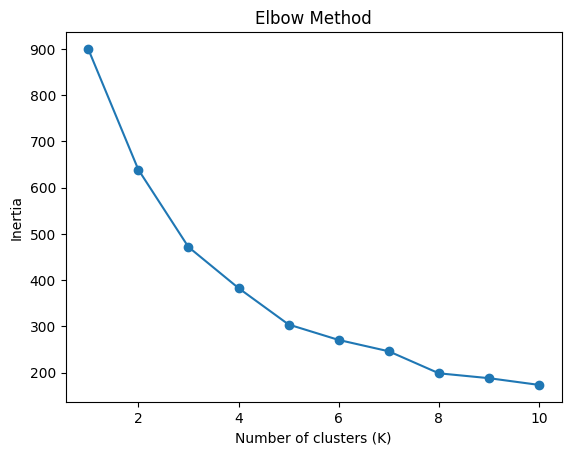

In [9]:
inertia = []
k_values = range(1,11)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.figure()
plt.plot(k_values, inertia, marker='o')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

## Spectral Clustering

In [10]:
optimal_k = 5

spectral = SpectralClustering(n_clusters=optimal_k, affinity='nearest_neighbors', random_state=42)
df['spectral_cluster'] = spectral.fit_predict(X_scaled)

df[['spectral_cluster']].head()

,spectral_cluster
0,0
1,4
2,1
3,1
4,1


## Visualize Spectral Clusters

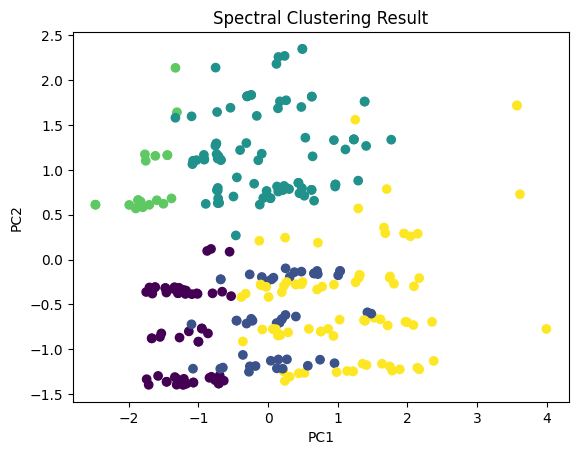

In [11]:
plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['spectral_cluster'])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Spectral Clustering Result')
plt.show()

## MOS per Spectral Cluster

In [12]:
df.groupby('spectral_cluster')['MOS'].mean()

spectral_cluster
0    2.644068
1    2.160000
2    4.523256
3    4.421053
4    2.604651
Name: MOS, dtype: float64

## Attribute Relationships inside Each Cluster

In [13]:
for cluster in sorted(df['spectral_cluster'].unique()):
    print('\nCluster', cluster)
    cluster_df = df[df['spectral_cluster']==cluster]
    print(cluster_df[qos_features + ['MOS']].corr())


Cluster 0
                 QoS_bandwidth  QoS_packet-loss  QoS_delay  QoS_jitter  \
QoS_bandwidth         1.000000              NaN   0.062347    0.013987   
QoS_packet-loss            NaN              NaN        NaN         NaN   
QoS_delay             0.062347              NaN   1.000000   -0.386377   
QoS_jitter            0.013987              NaN  -0.386377    1.000000   
MOS                   0.532091              NaN  -0.066990    0.197219   

                      MOS  
QoS_bandwidth    0.532091  
QoS_packet-loss       NaN  
QoS_delay       -0.066990  
QoS_jitter       0.197219  
MOS              1.000000  

Cluster 1
                 QoS_bandwidth  QoS_packet-loss  QoS_delay  QoS_jitter  \
QoS_bandwidth         1.000000              NaN   0.188469    0.259500   
QoS_packet-loss            NaN              NaN        NaN         NaN   
QoS_delay             0.188469              NaN   1.000000    0.359366   
QoS_jitter            0.259500              NaN   0.359366    1.00000

## QoE Anomaly Detection

In [14]:
cluster_mean = df.groupby('spectral_cluster')['MOS'].transform('mean')
df['qoe_anomaly'] = df['MOS'] < (0.5 * cluster_mean)

print('Number of QoE anomalies detected:', df['qoe_anomaly'].sum())

Number of QoE anomalies detected: 38


## Visualize QoE Anomalies

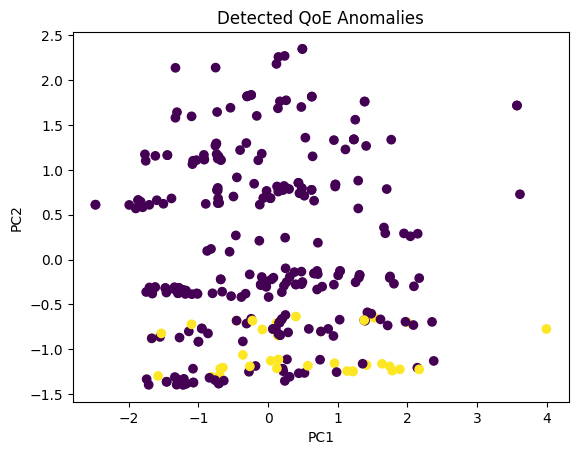

In [15]:
plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['qoe_anomaly'])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Detected QoE Anomalies')
plt.show()